In [1]:
import winsound
import cpip
import importlib
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display
from traitlets import HasTraits, Int
import ipywidgets as w
import time
importlib.reload(cpip)

<module 'cpip' from 'C:\\Users\\PC\\Desktop\\PYTHON\\cpip.py'>

In [34]:
class PID():
    def __init__(self, setpoint=180, kp=0, ki=0, kd=0, max_torque=300, limit_theta_abs=25,d_filter_alpha = 1):
        self.setpoint = setpoint
        self.max_torque = max_torque
        self.limit_theta_abs = limit_theta_abs
        self.kp, self.ki, self.kd = kp, ki, kd
        self.aP, self.aI, self.aD, self.action = 0, 0, 0, 0
        self.last_error = 0
        self.sum_error = 0
        self.dt_average = 0.002067944210497792
        self.current_time = 0
        self.last_time = 0
        self.dt = 0
        self.d_filter_alpha = d_filter_alpha
        self.history = []
    
    def __call__(self, theta, x, new_turn):
        self.current_time = time.perf_counter()
        self.dt = self.current_time - self.last_time
        self.last_time = self.current_time
        
        if new_turn:
            self.sum_error = 0
            self.last_error = self.setpoint - theta
            self.history = []
            self.dt = self.dt_average
            
        error = self.setpoint - theta


        d_error = (error - self.last_error)/self.dt
        self.sum_error += self.ki * error * self.dt
        

        self.aP = self.kp * error
        self.aI = self.sum_error
        self.aD = self.kd * d_error
        self.action = self.aP + self.aI + self.aD
 
        self.history.append((self.action, self.aP, self.aI, self.aD, theta, x, self.dt))
        
        self.last_error = error
        
        return self.action

controller = PID()

In [35]:
controller.kp = 52
controller.ki = 1/0.002067944210497792
controller.kd = 300*0.002067944210497792

controller.d_filter_alpha = 1

In [39]:
driver = cpip.MotorDriver(controller=controller, max_torque=600, limit_theta_abs=15)

Пронајдени се повеќе етернет адаптери, го користиме последниот во листата \Device\NPF_{74130C1F-BE8D-4666-A8B2-86775047A9D5}.
Пронајден е двигателот на моторот.


C:\Users\PC\Desktop\PYTHON\cpip.py:120: FutureWarning: This way of catching emergency messages is deprecated, use the add_emergency_callback() function!
  pulses = self.slave.sdo_read(MOTOR_ENCODER, SUBINDEX)
Exception in thread Thread-15 (watchdog):
Traceback (most recent call last):
  File "C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\PC\Desktop\PYTHON\cpip.py", line 135, in watchdog
    self.control_loop()
  File "C:\Users\PC\Desktop\PYTHON\cpip.py", line 159, in control_loop
    x = self.read_x()
        ^^^^^^^^^^^^^
  File "C:\Users\PC\Desktop\PYTHON\cpip.py", line 126, in read_x
    u_pulses = se

In [42]:
controller.aP, controller.aI, controller.aD, controller.action

(1.872000000000071, -16.37889470121758, 4.5000599383438, -10.006834762873709)

In [41]:
driver.read_theta()

0.0

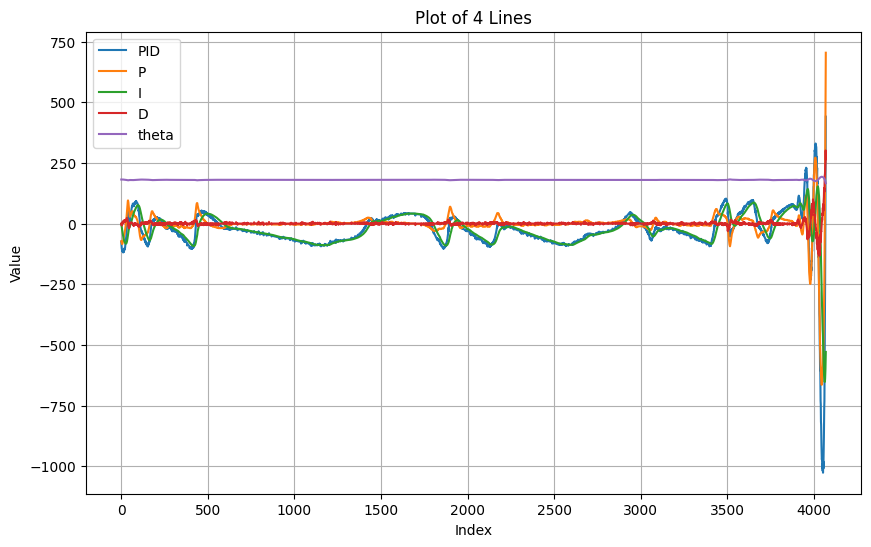

In [43]:
import matplotlib.pyplot as plt

# Unpack data into individual lists for each line
line1, line2, line3, line4, line5, line6, line7 = zip(*controller.history)

# Create an index for the x-axis (e.g., steps or time)
x_values = list(range(len(controller.history)))

# Plotting the 4 lines
plt.figure(figsize=(10, 6))

    
plt.plot(x_values, line1, label="PID")
plt.plot(x_values, line2, label="P")
plt.plot(x_values, line3, label="I")
plt.plot(x_values, line4, label="D")
plt.plot(x_values, line5, label="theta")

# Adding titles and labels
plt.title("Plot of 4 Lines")
plt.xlabel("Index")
plt.ylabel("Value")

# Adding a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


In [12]:
import numpy as np
import matplotlib.pyplot as plt

Total points: 56060
Downsampled points: 56060


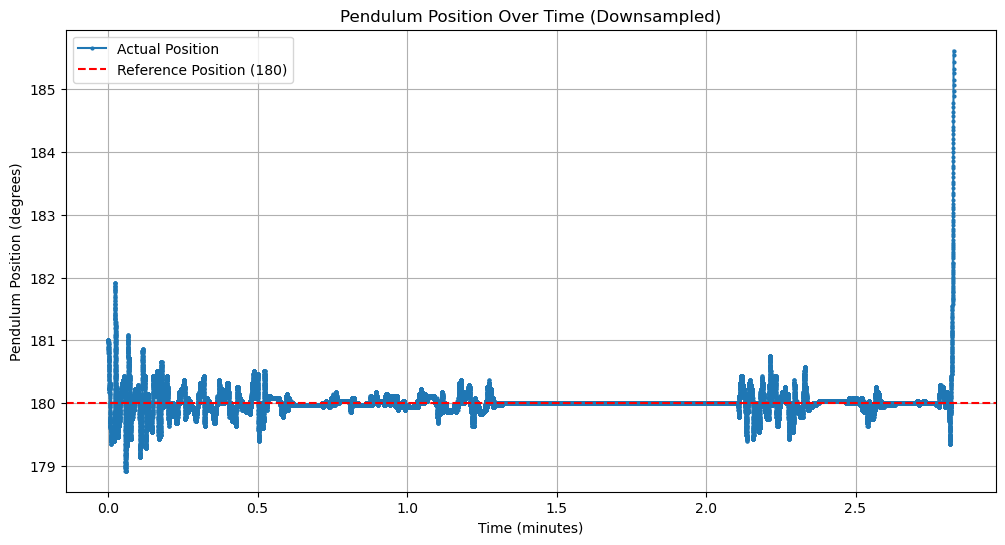

In [47]:
positions = [entry[4] for entry in controller.history]  # 5th element
dt = [entry[6] for entry in controller.history]         # 6th element

time = np.cumsum(dt)  # Time in seconds
time_ms = time/60   # Convert to milliseconds

# Downsample the data (e.g., every 10th point)
step = 1  # Adjust the step size as needed
time_ms_downsampled = time_ms[::step]
positions_downsampled = positions[::step]

# Debugging output (optional)
print("Total points:", len(controller.history))
print("Downsampled points:", len(positions_downsampled))

# Reference position
reference_position = 180

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(time_ms_downsampled, positions_downsampled, label='Actual Position', marker='o', markersize=2)
plt.axhline(y=reference_position, color='r', linestyle='--', label='Reference Position (180)')

# Adding labels and legend
plt.xlabel('Time (minutes)')
plt.ylabel('Pendulum Position (degrees)')
plt.title('Pendulum Position Over Time (Downsampled)')
plt.legend()
plt.grid(True)
# Show the plot
plt.savefig("response2.png") 
plt.show()

In [51]:
driver.read_theta()

0.0

In [120]:
driver.read_x()

211.61690625

In [24]:
controller.history

[(-4764.059999999958,
  -552.2399999999943,
  -10.61999999999989,
  -4201.199999999963,
  190.6199999999999,
  160.526625,
  0.002067944210497792)]